### SVM For Homes A, B & C

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

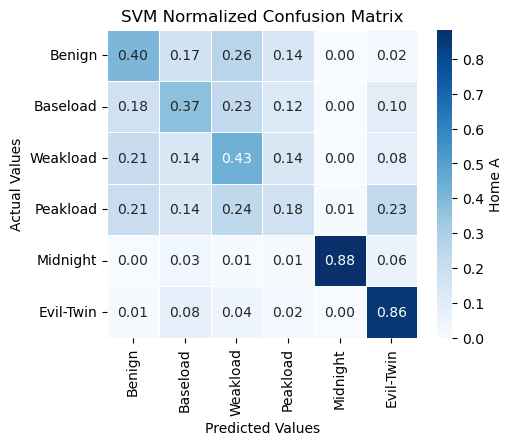

Accuracy Score: 0.5229885057471264
              precision    recall  f1-score   support

           0       0.40      0.40      0.40       146
           1       0.40      0.37      0.39       146
           2       0.36      0.43      0.39       146
           3       0.28      0.18      0.22       140
           4       0.99      0.88      0.93       146
           5       0.64      0.86      0.73       146

    accuracy                           0.52       870
   macro avg       0.51      0.52      0.51       870
weighted avg       0.51      0.52      0.51       870



<Figure size 640x480 with 0 Axes>

In [21]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Creating and fitting the SVC model
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\svm_cm.png', bbox_inches='tight')
# plt.savefig('/content/drive/My Drive/PowerStealAttack/svm_cm.eps', bbox_inches='tight')

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))


### Experiment with AUC Score¶

## Home A

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

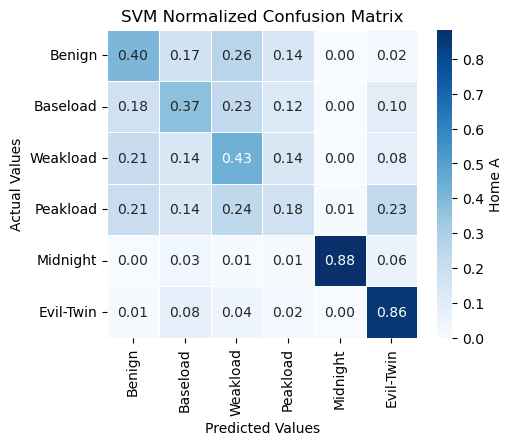

Accuracy Score: 0.5229885057471264
              precision    recall  f1-score   support

           0       0.40      0.40      0.40       146
           1       0.40      0.37      0.39       146
           2       0.36      0.43      0.39       146
           3       0.28      0.18      0.22       140
           4       0.99      0.88      0.93       146
           5       0.64      0.86      0.73       146

    accuracy                           0.52       870
   macro avg       0.51      0.52      0.51       870
weighted avg       0.51      0.52      0.51       870

AUC Score: 0.768634200444728


<Figure size 640x480 with 0 Axes>

In [22]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_svm_cm.png', bbox_inches='tight')

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### Experiment with AUC Score¶

## Home B

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

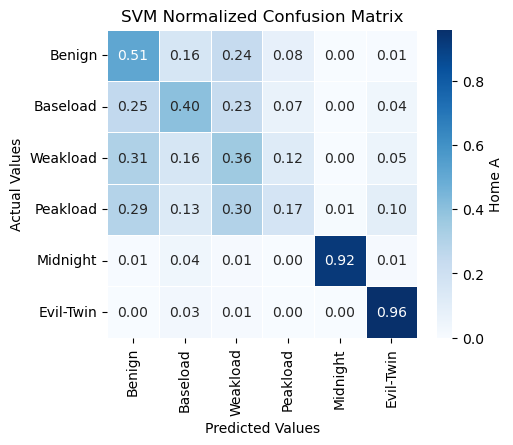

Accuracy Score: 0.5616279069767441
              precision    recall  f1-score   support

           0       0.38      0.51      0.44       146
           1       0.45      0.40      0.42       146
           2       0.32      0.36      0.34       146
           3       0.35      0.17      0.23       130
           4       0.99      0.92      0.96       146
           5       0.82      0.96      0.89       146

    accuracy                           0.56       860
   macro avg       0.55      0.55      0.55       860
weighted avg       0.56      0.56      0.55       860

AUC Score: 0.8119538430054143


<Figure size 640x480 with 0 Axes>

In [17]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_svm_cm.png', bbox_inches='tight')

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### Experiment with AUC Score

## Home C

    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

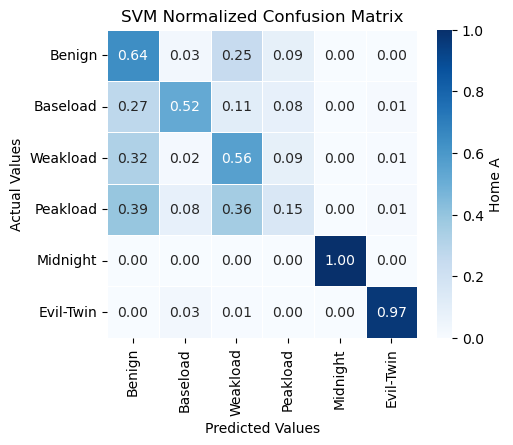

Accuracy Score: 0.6769041769041769
              precision    recall  f1-score   support

           0       0.44      0.64      0.52       146
           1       0.81      0.52      0.63       146
           2       0.50      0.56      0.53       146
           3       0.25      0.15      0.19        84
           4       1.00      1.00      1.00       146
           5       0.97      0.97      0.97       146

    accuracy                           0.68       814
   macro avg       0.66      0.64      0.64       814
weighted avg       0.69      0.68      0.67       814

AUC Score: 0.8962543927148964


<Figure size 640x480 with 0 Axes>

In [15]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_C_svm_cm.png', bbox_inches='tight')

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### Experiment with ROC_AUC Score

## Home A

C:\Users\olufe\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:612: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)
C:\Users\olufe\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:612: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\multiclass.py:79: UserWarning: Label not 0 is present in all training examples.
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\multiclass.py:79: UserWarning: Label not 1 is present in all training examples.
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\multiclass.py:79: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\multiclass.py:79: UserWarning: Label not 3 is present in all trai

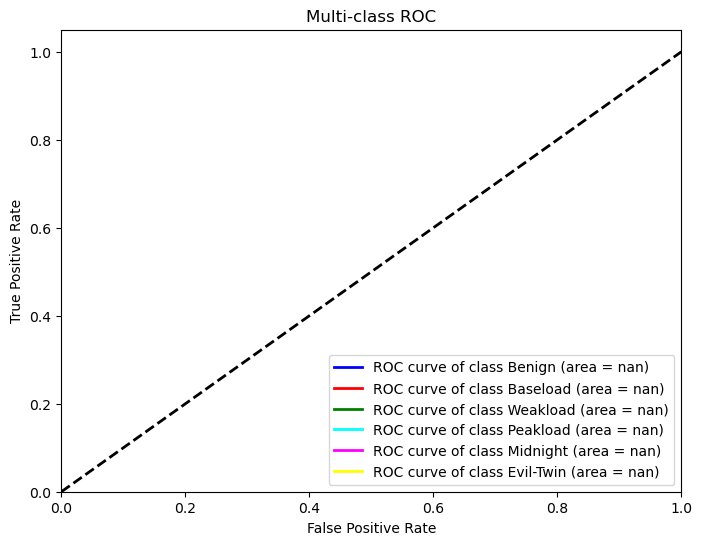

In [20]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle
from sklearn.multiclass import OneVsRestClassifier

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

#####################################################
# Preparing the training and testing data
# X_train = df_tr.drop(['Label'], axis=1)
# y_train = df_tr['Label']
# X_test = df_t.drop(['Label'], axis=1)
# y_test = df_t['Label']

# Binarize the output
classes = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin']
y_train_binarized = label_binarize(y_train, classes=classes)
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_train_binarized.shape[1]

# Creating and fitting the SVC model within OneVsRestClassifier
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True))
svc.fit(X_train, y_train_binarized)

# Predict probabilities
y_pred_prob = svc.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.show()

####################################################


# Binarize the output
# classes = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin']
# y_train_binarized = label_binarize(y_train, classes=classes)
# y_test_binarized = label_binarize(y_test, classes=classes)

# # Creating and fitting the SVC model with probability=True
# svc = SVC(kernel='linear', probability=True)
# svc.fit(X_train, y_train_binarized)

# # Predict probabilities
# y_pred_prob = svc.predict_proba(X_test)

# # Compute ROC curve and ROC area for each class
# fpr = dict()
# tpr = dict()
# roc_auc = dict()
# n_classes = len(classes)
# for i in range(n_classes):
#     fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
#     roc_auc[i] = auc(fpr[i], tpr[i])

# # Plot all ROC curves
# plt.figure(figsize=(8, 6))
# colors = cycle(['blue', 'red', 'green', 'cyan', 'magenta', 'yellow'])
# for i, color in zip(range(n_classes), colors):
#     plt.plot(fpr[i], tpr[i], color=color, lw=2,
#              label='ROC curve of class {0} (area = {1:0.2f})'
#                    ''.format(classes[i], roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Multi-class ROC')
# plt.legend(loc="lower right")
# plt.show()


### Experiment with AUC Score

## Home B

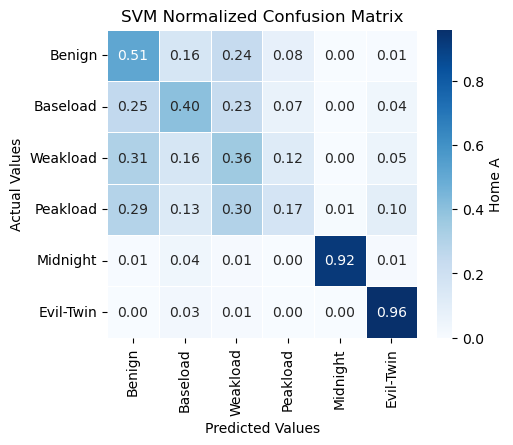

Accuracy Score: 0.5616279069767441
              precision    recall  f1-score   support

           0       0.38      0.51      0.44       146
           1       0.45      0.40      0.42       146
           2       0.32      0.36      0.34       146
           3       0.35      0.17      0.23       130
           4       0.99      0.92      0.96       146
           5       0.82      0.96      0.89       146

    accuracy                           0.56       860
   macro avg       0.55      0.55      0.55       860
weighted avg       0.56      0.56      0.55       860

AUC Score: 0.8142384828887649


<Figure size 640x480 with 0 Axes>

In [13]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
# print(df_t.head(5))
# print(df_tr.head(5))

# Checking data types
# print(df_t.dtypes)
# print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_B_svm_cm.png', bbox_inches='tight')

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

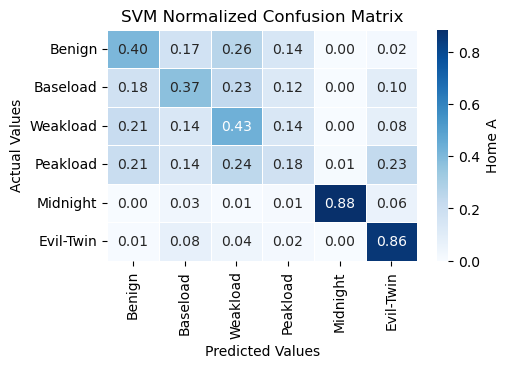

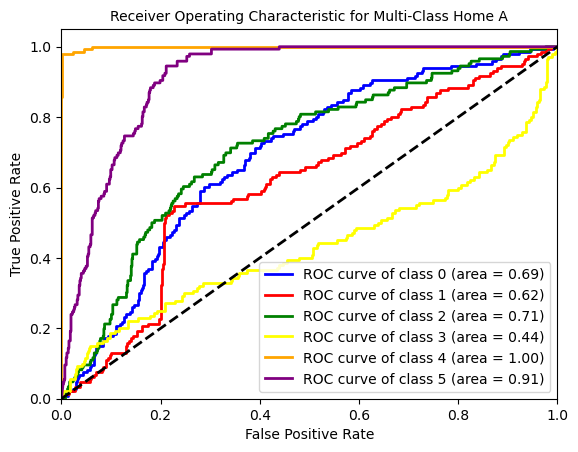

Accuracy Score: 0.5229885057471264
              precision    recall  f1-score   support

           0       0.40      0.40      0.40       146
           1       0.40      0.37      0.39       146
           2       0.36      0.43      0.39       146
           3       0.28      0.18      0.22       140
           4       0.99      0.88      0.93       146
           5       0.64      0.86      0.73       146

    accuracy                           0.52       870
   macro avg       0.51      0.52      0.51       870
weighted avg       0.51      0.52      0.51       870

AUC Score: 0.7665754956338094


In [27]:
# Importing packages
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import seaborn as sns
import matplotlib.pyplot as plt


# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']


# Binarize the output
classes = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin']
y_train_binarized = label_binarize(y_train, classes=np.unique(y_train))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_train_binarized.shape[1]

# Creating and fitting the SVC model with OneVsRestClassifier
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True))
svc.fit(X_train, y_train_binarized)

# Using the model to get predictions
y_pred_proba = svc.predict_proba(X_test)# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\svm_cm.png', bbox_inches='tight')
plt.show()


# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()

colors = cycle(['blue', 'red', 'green', 'yellow', 'orange', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class Home A', fontsize=10)
plt.legend(loc="lower right")
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_A_ROC_cm.png', bbox_inches='tight')
plt.show()


# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


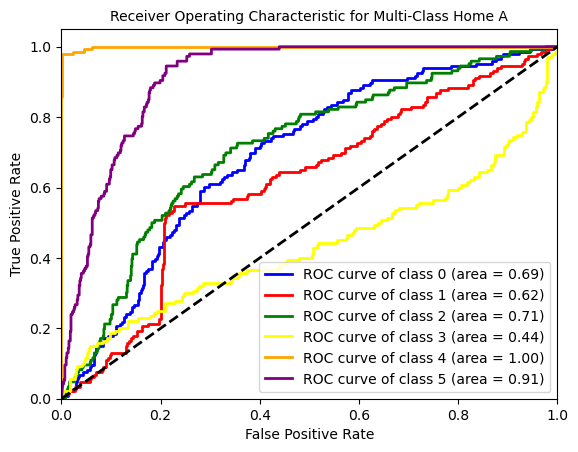

In [26]:
# Plot all ROC curves
plt.figure()

colors = cycle(['blue', 'red', 'green', 'yellow', 'orange', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class Home A', fontsize=10)
plt.legend(loc="lower right")
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_A_ROC_cm.png', bbox_inches='tight')
plt.show()

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

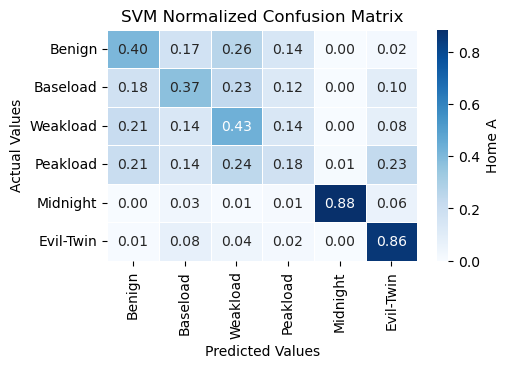

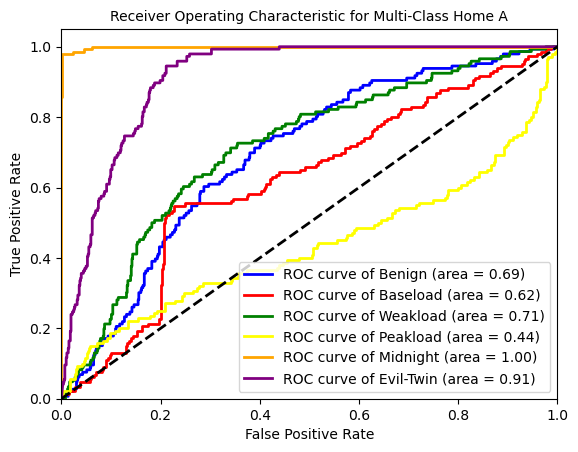

Accuracy Score: 0.5229885057471264
              precision    recall  f1-score   support

           0       0.40      0.40      0.40       146
           1       0.40      0.37      0.39       146
           2       0.36      0.43      0.39       146
           3       0.28      0.18      0.22       140
           4       0.99      0.88      0.93       146
           5       0.64      0.86      0.73       146

    accuracy                           0.52       870
   macro avg       0.51      0.52      0.51       870
weighted avg       0.51      0.52      0.51       870



NameError: name 'roc_auc_score' is not defined

In [3]:
# Importing packages
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import seaborn as sns
import matplotlib.pyplot as plt


# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']


# Binarize the output
classes = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin']
y_train_binarized = label_binarize(y_train, classes=np.unique(y_train))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_train_binarized.shape[1]

# Creating and fitting the SVC model with OneVsRestClassifier
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True))
svc.fit(X_train, y_train_binarized)

# Using the model to get predictions
y_pred_proba = svc.predict_proba(X_test)# Creating and fitting the SVC model
svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
svc.fit(X_train, y_train)

# Using the model to get predictions
y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 3))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('SVM Normalized Confusion Matrix')
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\svm_cm.png', bbox_inches='tight')
plt.show()


# Existing code remains the same ...

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()

colors = cycle(['blue', 'red', 'green', 'yellow', 'orange', 'purple'])
class_labels = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'] # Class names
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_labels[i]} (area = {roc_auc[i]:0.2f})') # Updated line

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class Home A', fontsize=10)
plt.legend(loc="lower right")
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_A_ROC_cm.png', bbox_inches='tight')
plt.show()

# Rest of the code...

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")

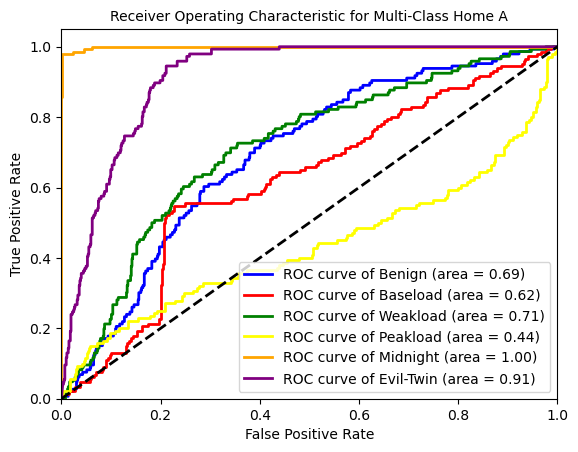

Accuracy Score: 0.5229885057471264
              precision    recall  f1-score   support

           0       0.40      0.40      0.40       146
           1       0.40      0.37      0.39       146
           2       0.36      0.43      0.39       146
           3       0.28      0.18      0.22       140
           4       0.99      0.88      0.93       146
           5       0.64      0.86      0.73       146

    accuracy                           0.52       870
   macro avg       0.51      0.52      0.51       870
weighted avg       0.51      0.52      0.51       870

AUC Score: 0.7672710047464077


In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# Plot all ROC curves
plt.figure()

colors = cycle(['blue', 'red', 'green', 'yellow', 'orange', 'purple'])
class_labels = ['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'] # Class names
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_labels[i]} (area = {roc_auc[i]:0.2f})') # Updated line

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class Home A', fontsize=10)
plt.legend(loc="lower right")
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\Home_A_ROC_cm.png', bbox_inches='tight')
plt.show()

# Rest of the code...

# Evaluating accuracy
accuracy_score = svc.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_prob = svc.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")